# Train YOLO11 on Fashion Dataset

### Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import cv2
import shutil
import tqdm
import glob

In [2]:
# Check GPU is working or not
import torch
print(f"Using torch {torch.__version__} ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})")

Using torch 2.8.0 (CPU)


### Load images

In [3]:
images_path = '/Users/tracieluong/Documents/colorful_fashion_dataset_for_object_detection/JPEGImages/'
annotations_path  = '/Users/tracieluong/Documents/colorful_fashion_dataset_for_object_detection/Annotations_txt/'
path = '/Users/tracieluong/Documents/colorful_fashion_dataset_for_object_detection/'

### Test YOLO11 model on a sample image

In [4]:
from ultralytics import YOLO

# load pre-trained model
detection_model = YOLO("yolo11m.pt")


image 1/1 /Users/tracieluong/Documents/colorful_fashion_dataset_for_object_detection/JPEGImages/190770.jpg: 640x448 1 person, 1 handbag, 120.8ms
Speed: 4.2ms preprocess, 120.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /Users/tracieluong/Documents/github/vogue-runway-analysis/notebooks/runs/detect/predict


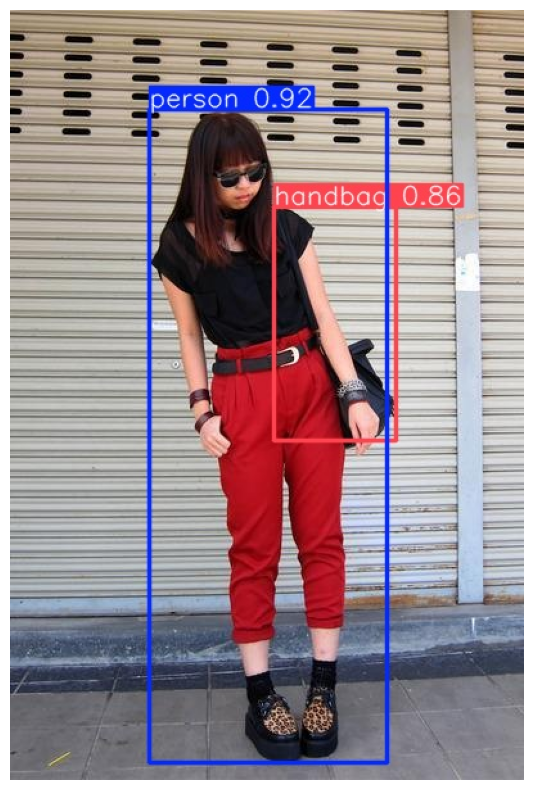

In [5]:
# choose random image
img = random.choice(os.listdir(images_path))
# build full path to the selected image
img_path = os.path.join(images_path, img)

# run prediction on the selected image and save results
i = detection_model.predict(source=img_path, conf=0.5, save=True, line_width=2, show_labels=True)

# output file is saved under runs/detect/predict with the same filename
out_path = os.path.join('runs', 'detect', 'predict', img)

im = plt.imread(out_path)
plt.figure(figsize=(20,10))
plt.axis('off')
plt.imshow(im)

### Prepare training and testing data sets

In [6]:
train = []
with open(path+'ImageSets/Main/trainval.txt', 'r') as f:
    for line in f.readlines():
        if line[-1]=='\n':
            line = line[:-1]
        train.append(line)

test = []
with open(path+'ImageSets/Main/test.txt', 'r') as f:
    for line in f.readlines():
        if line[-1]=='\n':
            line = line[:-1]
        test.append(line)

In [7]:
print("Number of images in training set:", len(train))
print("Number of images in test set:", len(test))

Number of images in training set: 2145
Number of images in test set: 537


In [ ]:
os.mkdir('../train')
os.mkdir('../train/images')
os.mkdir('../train/labels')

os.mkdir('../test')
os.mkdir('../test/images')
os.mkdir('../test/labels')

In [ ]:
train_path = '../train/'
test_path = '../test/'

print('Copying Train Data..!!')
for i in tqdm.tqdm(train):
    a = shutil.copyfile(images_path+i+'.jpg', train_path+'images/'+i+'.jpg')
    a = shutil.copyfile(annotations_path+i+'.txt', train_path+'labels/'+i+'.txt')

print('Copying Test Data..!!')
for i in tqdm.tqdm(test):
    a = shutil.copyfile(images_path+i+'.jpg', test_path+'images/'+i+'.jpg')
    a = shutil.copyfile(annotations_path+i+'.txt', test_path+'labels/'+i+'.txt')

Copying Train Data..!!


100%|██████████| 2145/2145 [00:01<00:00, 1673.72it/s]


Copying Test Data..!!


100%|██████████| 537/537 [00:00<00:00, 1826.72it/s]


### Train Custom Models for Clothing Detection

In [8]:
text = """
train: /Users/tracieluong/Documents/github/vogue-runway-analysis/train
val: /Users/tracieluong/Documents/github/vogue-runway-analysis/test

# number of classes
nc: 10

# class names
names: ['sunglass','hat','jacket','shirt','pants','shorts','skirt','dress','bag','shoe']
"""
with open("../data.yaml", 'w') as file:
    file.write(text)

In [9]:
model = YOLO("yolo11m.pt")

model.train(data='../data.yaml', epochs=5)

Ultralytics 8.3.204 🚀 Python-3.9.6 torch-2.8.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, pr

KeyboardInterrupt: 